In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
)

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer, label_binarize
from sklearn.dummy import DummyClassifier

from fim import fpgrowth

import plotly.graph_objs as go
import time

# Pre-processing
We don't log transform `runtimeMinutes` for increased readability. We bin numeric variables, and for all variables we add the semantics to the values.

In [2]:
# Train

df = pd.read_csv("../results/train_clean.csv", index_col=0)
df['countryOfOrigin'] = df['countryOfOrigin'].apply(ast.literal_eval)
df['genres'] = df['genres'].apply(ast.literal_eval)
#df['logRuntime'] = np.log(df['runtimeMinutes'] + 1)
df.drop(columns=['originalTitle', 'ratingNum'], inplace=True)

# store a copy for later (classification)
df_copy = df.copy()

In [3]:
# Test

df_test = pd.read_csv("../results/test_clean.csv", index_col=0)
df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
#df_test['logRuntime'] = np.log(df_test['runtimeMinutes'] + 1)
df_test.drop(columns=['originalTitle','ratingNum'], inplace=True)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16431 entries, 0 to 16430
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rating                 16431 non-null  object 
 1   startYear              16431 non-null  int64  
 2   runtimeMinutes         16431 non-null  float64
 3   numVotes               16431 non-null  float64
 4   totalImages            16431 non-null  float64
 5   totalCredits           16431 non-null  float64
 6   titleType              16431 non-null  object 
 7   canHaveEpisodes        16431 non-null  bool   
 8   numRegions             16431 non-null  float64
 9   countryOfOrigin        16431 non-null  object 
 10  genres                 16431 non-null  object 
 11  numGenres              16431 non-null  int64  
 12  criticReviewsRatio     16431 non-null  float64
 13  awardsAndNominations   16431 non-null  bool   
 14  hasVideos              16431 non-null  bool   
 15  moreCou

Discretization of numeric attributes (into quartile-based bins):

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# numGenres: the values are 1,2,3 → no binning, just as string
num_cols = num_cols.drop(['numGenres'])
num_cols

Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
       'totalCredits', 'numRegions', 'criticReviewsRatio'],
      dtype='object')

In [6]:
# Discretize training set and store bin edges
df["startYearBin"], startYearBins = pd.qcut(df["startYear"], 4, retbins=True, duplicates='drop')
df["runtimeBin"], runtimeBins = pd.qcut(df["runtimeMinutes"], 4, retbins=True, duplicates='drop')
df["numVotesBin"], numVotesBins = pd.qcut(df["numVotes"], 4, retbins=True, duplicates='drop')
df["totalImagesBin"], totalImagesBins = pd.qcut(df["totalImages"], 4, retbins=True, duplicates='drop')
df["totalCreditsBin"], totalCreditsBins = pd.qcut(df["totalCredits"], 4, retbins=True, duplicates='drop')
df['numRegionsBin'], numRegionsBins = pd.qcut(df['numRegions'], 4, retbins=True, duplicates='drop')
#df["numGenresBin"], numGenresBins = pd.qcut(df["numGenres"], 4, retbins=True, duplicates='drop')
df["criticReviewsRatioBin"], criticReviewsRatioBins = pd.qcut(df["criticReviewsRatio"], 4, retbins=True, duplicates='drop')

In [7]:
# print the bin edges
print("Start Year Bins:", startYearBins)
print("Runtime Bins:", runtimeBins)
print("Number of Votes Bins:", numVotesBins)
print("Total Images Bins:", totalImagesBins)
print("Total Credits Bins:", totalCreditsBins)
print("Number of Regions Bins:", numRegionsBins)
#print("Number of Genres Bins:", numGenresBins)
print("Critic Reviews Ratio Bins:", criticReviewsRatioBins)


Start Year Bins: [1878. 1978. 1997. 2013. 2024.]
Runtime Bins: [   0.   29.   50.   90. 3000.]
Number of Votes Bins: [ 1.79175947  2.77258872  3.61091791  5.0072908  13.78150486]
Total Images Bins: [0.         0.69314718 1.94591015 8.1619458 ]
Total Credits Bins: [0.         2.83321334 3.55534806 4.18965474 9.6641511 ]
Number of Regions Bins: [0.69314718 1.38629436 4.24849524]
Critic Reviews Ratio Bins: [0.         0.22653959 1.        ]


In [8]:
df.drop(num_cols, axis=1, inplace=True)
#df_test.drop(num_cols, axis=1, inplace=True)

In [9]:
df.columns

Index(['rating', 'titleType', 'canHaveEpisodes', 'countryOfOrigin', 'genres',
       'numGenres', 'awardsAndNominations', 'hasVideos',
       'moreCountriesOfOrigin', 'startYearBin', 'runtimeBin', 'numVotesBin',
       'totalImagesBin', 'totalCreditsBin', 'numRegionsBin',
       'criticReviewsRatioBin'],
      dtype='object')

In [10]:
# add semantics to the values (also for rating and titleType)

# TRAIN
df["startYearBin"] = df["startYearBin"].astype(str) + "_StartYear"
df["runtimeBin"] = df["runtimeBin"].astype(str) + "_RuntimeMin"
df["numVotesBin"] = df["numVotesBin"].astype(str) + "_NumVotes"
df["totalImagesBin"] = df["totalImagesBin"].astype(str) + "_TotalImages"
df["totalCreditsBin"] = df["totalCreditsBin"].astype(str) + "_TotalCredits"
df["numRegionsBin"] = df["numRegionsBin"].astype(str) + "_NumRegions"
#df["numGenresBin"] = df["numGenresBin"].astype(str) + "_NumGenres"
df["criticReviewsRatioBin"] = df["criticReviewsRatioBin"].astype(str) + "_CriticReviewsRatio"

df["numGenres"] = df["numGenres"].astype(str) + "_NumGenres"
df["rating"] = df["rating"].astype(str) + "_Rating"
df["titleType"] = df["titleType"].astype(str) + "_TitleType"

Boolean attributes:

In [11]:
bool_cols = df.select_dtypes(include='bool').columns
print(bool_cols)

# True, False → 1, 0
for col in bool_cols:
    df[col] = df[col].astype(int)

Index(['canHaveEpisodes', 'awardsAndNominations', 'hasVideos',
       'moreCountriesOfOrigin'],
      dtype='object')


In [12]:
episode_dict = {0: "NoEpisodes", 1: "HasEpisodes"}
df["canHaveEpisodes"] = df["canHaveEpisodes"].map(episode_dict)

awards_dict = {0: "NoAwardsnorNominations", 1: "HasAwardsorNominations"}
df["awardsAndNominations"] = df["awardsAndNominations"].map(awards_dict)

videos_dict = {0: "NoVideos", 1: "HasVideos"}
df["hasVideos"] = df["hasVideos"].map(videos_dict)

more_countries_dict = {0: "OneCountryofOrigin", 1: "MoreCountriesOfOrigin"}
df["moreCountriesOfOrigin"] = df["moreCountriesOfOrigin"].map(more_countries_dict)

Multi-label categorical attributes:
- Multi-label variables: We first binarize `countryOfOrigin` and `genres`. Since `countryOfOrigin` has many unique values, we only keep the 4 most frequent to reduce dimensionality and noise from rare countries, collapsing all other countries to 'Other'.

In [13]:
mlb = MultiLabelBinarizer()

In [14]:
all_countries = [country for countries in df['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 4
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)])

def clean_countries(countries):
    return [c if c in top_countries else "Other" for c in countries]

df['country_cleaned'] = df['countryOfOrigin'].apply(clean_countries)

In [15]:
# Country Binarizer
mlb_country = MultiLabelBinarizer()
country_train = mlb_country.fit_transform(df['country_cleaned'])

country_cols = [f"country_{c}" for c in mlb_country.classes_]
countries_df = pd.DataFrame(country_train, columns=country_cols, index=df.index)

# Genre Binarizer
mlb_genre = MultiLabelBinarizer()
genre_train = mlb_genre.fit_transform(df['genres'])

genre_cols = [f"genre_{c}" for c in mlb_genre.classes_]
genres_df = pd.DataFrame(genre_train, columns=genre_cols, index=df.index)


In [16]:
df = df.join(countries_df)
df = df.join(genres_df)
df.drop(columns=['genres', 'countryOfOrigin', 'country_cleaned'], inplace=True)


In [17]:
df.columns

Index(['rating', 'titleType', 'canHaveEpisodes', 'numGenres',
       'awardsAndNominations', 'hasVideos', 'moreCountriesOfOrigin',
       'startYearBin', 'runtimeBin', 'numVotesBin', 'totalImagesBin',
       'totalCreditsBin', 'numRegionsBin', 'criticReviewsRatioBin',
       'country_FR', 'country_GB', 'country_JP', 'country_Other', 'country_US',
       'genre_Action', 'genre_Adult', 'genre_Adventure', 'genre_Animation',
       'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Documentary',
       'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Film-Noir',
       'genre_Game-Show', 'genre_History', 'genre_Horror', 'genre_Music',
       'genre_Musical', 'genre_Mystery', 'genre_News', 'genre_Reality-TV',
       'genre_Romance', 'genre_Sci-Fi', 'genre_Short', 'genre_Sport',
       'genre_Talk-Show', 'genre_Thriller', 'genre_War', 'genre_Western'],
      dtype='object')

In [18]:
df.head()

,rating,titleType,canHaveEpisodes,numGenres,awardsAndNominations,hasVideos,moreCountriesOfOrigin,startYearBin,runtimeBin,numVotesBin,...,genre_News,genre_Reality-TV,genre_Romance,genre_Sci-Fi,genre_Short,genre_Sport,genre_Talk-Show,genre_Thriller,genre_War,genre_Western
0,"(7, 8]_Rating",tvEpisode_TitleType,NoEpisodes,3_NumGenres,NoAwardsnorNominations,NoVideos,OneCountryofOrigin,"(1978.0, 1997.0]_StartYear","(29.0, 50.0]_RuntimeMin","(5.007, 13.782]_NumVotes",...,0,0,0,0,0,0,0,0,0,0
1,"(5, 6]_Rating",videoGame_TitleType,NoEpisodes,1_NumGenres,NoAwardsnorNominations,NoVideos,OneCountryofOrigin,"(1978.0, 1997.0]_StartYear","(-0.001, 29.0]_RuntimeMin","(1.7910000000000001, 2.773]_NumVotes",...,0,0,0,0,0,0,0,0,0,0
2,"(5, 6]_Rating",movie_TitleType,NoEpisodes,1_NumGenres,NoAwardsnorNominations,NoVideos,OneCountryofOrigin,"(1978.0, 1997.0]_StartYear","(50.0, 90.0]_RuntimeMin","(3.611, 5.007]_NumVotes",...,0,0,0,0,0,0,0,0,0,0
3,"(5, 6]_Rating",tvSeries_TitleType,HasEpisodes,1_NumGenres,NoAwardsnorNominations,NoVideos,OneCountryofOrigin,"(2013.0, 2024.0]_StartYear","(29.0, 50.0]_RuntimeMin","(1.7910000000000001, 2.773]_NumVotes",...,0,1,0,0,0,0,0,0,0,0
4,"(7, 8]_Rating",tvSeries_TitleType,HasEpisodes,3_NumGenres,HasAwardsorNominations,HasVideos,OneCountryofOrigin,"(2013.0, 2024.0]_StartYear","(50.0, 90.0]_RuntimeMin","(5.007, 13.782]_NumVotes",...,0,0,1,0,0,0,0,0,0,0


We build our transactional dataset as a list of lists → each transaction (ie. record) is a list of items (values for the different attributes, as strings).

NB: not all records have the same lenght bc they can have 1+ values for countryOfOrigin and genres.

In [19]:
def dataframe_to_transactions(df):
    transactions = []
    for _, row in df.iterrows():
        transaction = []
        for col in df.columns:
            # one-hot encoded columns: add the column name as an item to the transaction if the value is 1, else skip it
            if col.startswith('genre_') or col.startswith('country_'):
                if row[col] == 1:
                    transaction.append(col)
            else:
                transaction.append(str(row[col]))  # add as items all other values (as strings)
        transactions.append(transaction)
    return transactions

In [20]:
X = dataframe_to_transactions(df)

In [21]:
X[0]

['(7, 8]_Rating',
 'tvEpisode_TitleType',
 'NoEpisodes',
 '3_NumGenres',
 'NoAwardsnorNominations',
 'NoVideos',
 'OneCountryofOrigin',
 '(1978.0, 1997.0]_StartYear',
 '(29.0, 50.0]_RuntimeMin',
 '(5.007, 13.782]_NumVotes',
 '(-0.001, 0.693]_TotalImages',
 '(2.833, 3.555]_TotalCredits',
 '(0.692, 1.386]_NumRegions',
 '(0.227, 1.0]_CriticReviewsRatio',
 'country_US',
 'genre_Action',
 'genre_Adventure',
 'genre_Animation']

# Frequent Itemsets Extraction

In [22]:
help(fpgrowth)

Help on built-in function fpgrowth in module fim:

fpgrowth(...)
    fpgrowth (tracts, target='s', supp=10, zmin=1, zmax=None, report='a',
              eval='x', agg='x', thresh=10, prune=Nobe, algo='s', mode='',
              border=None)
    Find frequent item sets with the FP-growth algorithm.
    tracts  transaction database to mine (mandatory)
            The database must be an iterable of transactions;
            each transaction must be an iterable of items;
            each item must be a hashable object.
            If the database is a dictionary, the transactions are
            the keys, the values their (integer) multiplicities.
    target  type of frequent item sets to find     (default: s)
            s/a   sets/all   all     frequent item sets
            c     closed     closed  frequent item sets
            m     maximal    maximal frequent item sets
            g     gens       generators
            r     rules      association rules
    supp    minimum support 

In [23]:
zmin = 2 # min 2 items in each itemset

It makes sense to explore minsup < 12, since after that we have close to 0 maximal and closed itemsets.

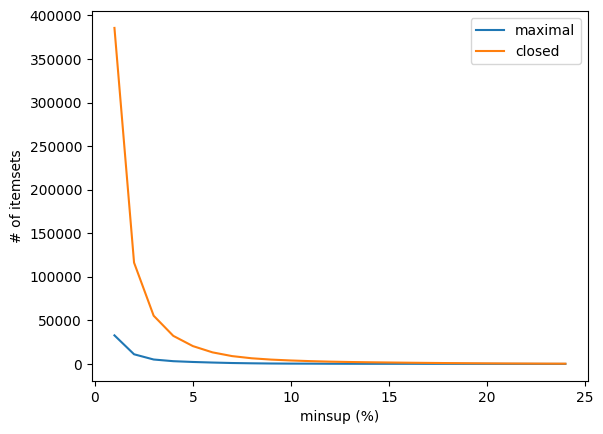

In [24]:
len_freq_it = [] # all frequent itemsets
len_max_it = [] # maximal
len_cl_it = [] # closed

max_supp = 25

for i in range(1, max_supp):
    freq_itemsets = fpgrowth(X, target="s", supp=i, zmin=zmin)
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    cl_itemsets = fpgrowth(X, target="c", supp=i, zmin=zmin)

    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))
    len_freq_it.append(len(freq_itemsets))
plt.plot(np.arange(1, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(1, max_supp), len_cl_it, label="closed")
#plt.plot(np.arange(1, max_supp), len_freq_it, label="all frequent")
plt.legend()
plt.xlabel("minsup (%)")
plt.ylabel("# of itemsets")

#plt.yscale('log')

plt.show()

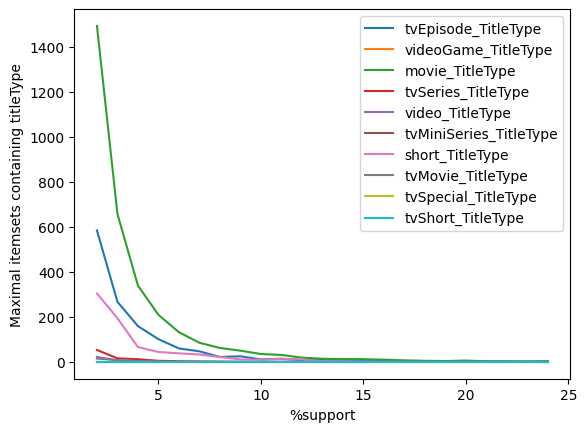

In [25]:
title_types = df['titleType'].unique()
results = {tt: [] for tt in title_types}

for i in range(2, max_supp):
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    for tt in title_types:
        results[tt].append(len([item for item in max_itemsets if tt in item[0]]))

for tt in title_types:
    plt.plot(np.arange(2, max_supp), results[tt], label=tt)

plt.legend()
plt.xlabel("%support")
plt.ylabel("Maximal itemsets containing titleType")
plt.show()

In [26]:
x = np.arange(2, max_supp)
fig = go.Figure()

for tt in title_types:
    fig.add_trace(go.Scatter(x=x, y=results[tt], mode='lines', name=tt))

fig.update_layout(
    title="Maximal itemsets containing titleType",
    xaxis_title="%support",
    yaxis_title="Maximal itemsets containing titleType",
    legend_title="titleType"
)
fig.show()

 The different number of maximal itemsets reflects the different popularity of the classes. No maximal itemsets across thresholds for minority classes: `tvShort`, `videoGame`, `tvMiniSeries`, `tvSpecial`.
After minsup > 4, we start the remaining "losing" classes.

In [27]:
supp = 30  # 20%
zmin = 2  # minimum number of items per item set
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [28]:
# CLOSED ITEMSETS
closed_itemsets = fpgrowth(X, target="c", supp=supp, zmin=zmin, report="S")
pd.DataFrame(closed_itemsets, columns=["closed_itemset", "support"]).sort_values(by="support", ascending=False).head(10)

,closed_itemset,support
172,"(NoVideos, OneCountryofOrigin)",84.748342
173,"(NoEpisodes, OneCountryofOrigin)",83.908466
171,"(NoVideos, NoEpisodes)",81.760088
169,"(NoAwardsnorNominations, OneCountryofOrigin)",78.911813
166,"(NoAwardsnorNominations, NoVideos)",77.840667
170,"(NoVideos, NoEpisodes, OneCountryofOrigin)",76.733005
168,"(NoAwardsnorNominations, NoEpisodes)",75.862699
165,"(NoAwardsnorNominations, NoVideos, OneCountryofOrigin)",73.982107
162,"((0.692, 1.386]_NumRegions, OneCountryofOrigin)",71.918934
167,"(NoAwardsnorNominations, NoEpisodes, OneCountryofOrigin)",71.827643


In [29]:
# MAXIMAL ITEMSETS
maximal_itemsets = fpgrowth(X, target="m", supp=supp, zmin=zmin, report="S")
pd.DataFrame(maximal_itemsets, columns=["maximal_itemset", "support"]).sort_values(by="support", ascending=False).head(10)

,maximal_itemset,support
3,"(movie_TitleType, NoEpisodes)",33.686325
9,"(1_NumGenres, NoVideos, OneCountryofOrigin)",33.631550
16,"(country_Other, NoVideos, NoEpisodes)",32.767330
17,"(country_Other, NoVideos, OneCountryofOrigin)",32.481285
19,"(country_US, (-0.001, 0.227]_CriticReviewsRatio)",31.537947
13,"(genre_Drama, NoEpisodes, OneCountryofOrigin)",31.513602
1,"((50.0, 90.0]_RuntimeMin, NoEpisodes)",31.471000
15,"(country_Other, NoAwardsnorNominations)",31.349279
14,"(country_Other, (-0.001, 0.227]_CriticReviewsRatio)",31.331021
24,"(country_US, NoAwardsnorNominations, NoVideos, NoEpisodes, OneCountryofOrigin)",31.057148


At support = 30, we find some interesting Maximal itemsets, rather than just a combination of all most frequent values (problem of such an unblanced dataset).
- 3: logical → movies shouldn't be tagget as having episodes
- 1: runtime typical of that of a movie → shouldn't have episodes
- 13: dramatic stand-alone title (not series) from a single country. Could be a movie, telenovela episode, ...
- 17: foreign title

# Association Rules Extraction


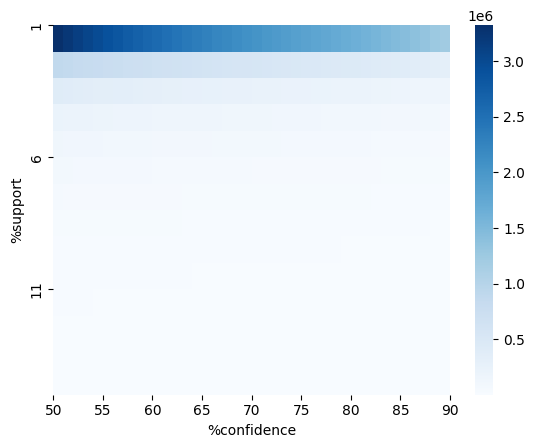

In [30]:
len_r = []
min_sup = 1
max_sup = 15
min_conf = 50
max_conf = 90

for i in range(min_sup, max_sup):  # support
    len_r_wrt_i = []
    for j in range(min_conf, max_conf):  # confidence
        rules = fpgrowth(X, target="r", supp=i, zmin=zmin, conf=j, report="aScl")
        len_r_wrt_i.append(len(rules))  # study your characteristics/properties here

    len_r.append(len_r_wrt_i)
len_r = np.array(len_r)
sns.heatmap(len_r, cmap="Blues", fmt='g')
plt.yticks(np.arange(0, max_sup-min_sup +1, 5), np.arange(min_sup, max_sup+1,5 ))
plt.xticks(np.arange(0, max_conf-min_conf+1, 5), np.arange(min_conf, max_conf+1, 5))
plt.xlabel("%confidence")
plt.ylabel("%support")
plt.show()

The increasing support is the main filter. We explored different values of minsup keeping minconf low and fixed (65%), increasing by small increments. Once we found a value (which, as anticipated by the above plot, turned out to be relatively small) yielding an interesting list of rules, we increased conf, keeping an eye on rules having titleType as a consequent, as we want to use them for classification. We reached 80% confidence, before we'd lose interesting rules.

The rules w/ the highest lift all contain a title type either in the antecedent or consequent. In particular, the two highest rules have captured the property of "has episode" for tvSeries, and the rest have captured the fact that the information about "short" is captured in the genres.

In [31]:
conf = 80 # we tested from over 65%
zmin= 2
supp = 9
start = time.time()
rules = fpgrowth(X, target="r", supp=supp, zmin=zmin, conf=conf, report="aScl")
print(f"Time taken: {time.time() - start:.2f} seconds")
print(f"Total number of rules: {len(rules)}")

Time taken: 0.04 seconds
Total number of rules: 16466


In [32]:
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)

rules_df.sort_values(by="lift", axis=0, ascending=False).head(10)

,consequent,antecedent,abs_support,%_support,confidence,lift
16464,tvSeries_TitleType,"(HasEpisodes, OneCountryofOrigin)",1297,7.893616,0.865821,10.346405
16465,tvSeries_TitleType,"(HasEpisodes,)",1375,8.368328,0.859912,10.275797
15880,genre_Short,"(short_TitleType, (-0.001, 0.693]_TotalImages, NoEpisodes)",1393,8.477877,0.930528,6.205155
15888,genre_Short,"(short_TitleType, (-0.001, 0.693]_TotalImages)",1393,8.477877,0.930528,6.205155
16189,genre_Short,"(short_TitleType, (-0.001, 2.833]_TotalCredits, OneCountryofOrigin)",1379,8.392672,0.930499,6.204965
16191,genre_Short,"(short_TitleType, (-0.001, 2.833]_TotalCredits, NoEpisodes, OneCountryofOrigin)",1379,8.392672,0.930499,6.204965
15973,short_TitleType,"(genre_Short, (-0.001, 29.0]_RuntimeMin, (0.692, 1.386]_NumRegions, NoEpisodes, OneCountryofOrigin)",1862,11.332238,0.932866,6.195601
15978,short_TitleType,"(genre_Short, (-0.001, 29.0]_RuntimeMin, (0.692, 1.386]_NumRegions, NoEpisodes)",1920,11.685229,0.932492,6.193116
16193,genre_Short,"(short_TitleType, (-0.001, 2.833]_TotalCredits, NoEpisodes)",1410,8.581340,0.928242,6.189914
16199,genre_Short,"(short_TitleType, (-0.001, 2.833]_TotalCredits)",1410,8.581340,0.928242,6.189914


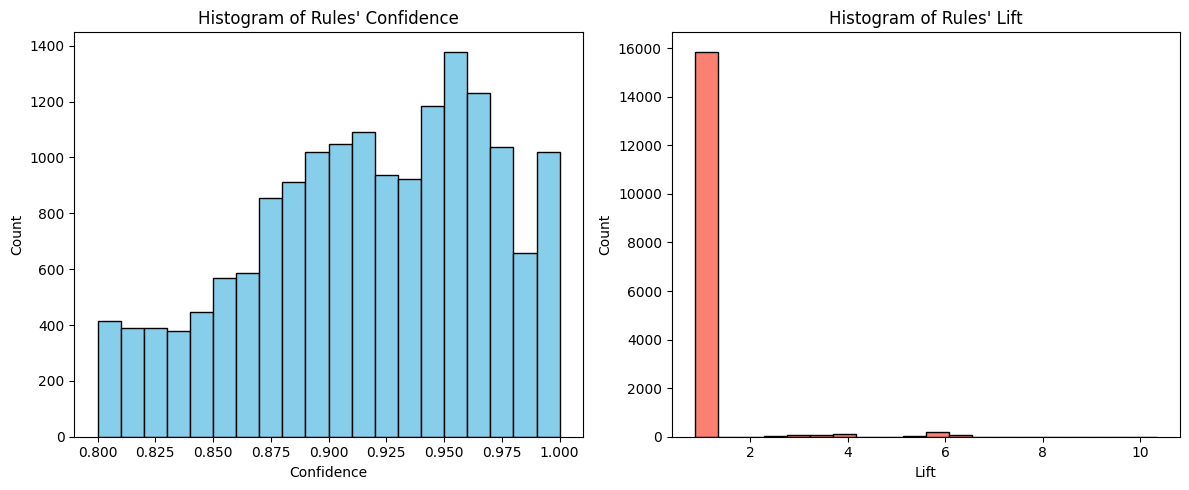

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(rules_df['confidence'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.title("Histogram of Rules' Confidence")

plt.subplot(1, 2, 2)
plt.hist(rules_df['lift'], bins=20, color='salmon', edgecolor='black')
plt.xlabel('Lift')
plt.ylabel('Count')
plt.title("Histogram of Rules' Lift")

plt.tight_layout()
plt.show()

Rules have high confidence, the most part fall above 0.88. Nevertheless, the large majority is weak, with a lift < 1. It's important we focus on high-lift rules.

Rules that contain a titleType as a consequent:

In [34]:
def consequent_contains_title_type(conseq):
    return any("TitleType" in item for item in conseq)

# Apply filter
titleType_rules_df = rules_df[
    rules_df["consequent"].str.contains("TitleType")
]

# Show result
total_rules_tt = len(titleType_rules_df)
print(f"{total_rules_tt} rules have 'TitleType' in the consequent.\n")

# Count occurrences of each titleType in the 'consequent' column
titletype_counts = titleType_rules_df['consequent'].value_counts()
for tt, count in titletype_counts.items():
    percent = 100 * count / total_rules_tt
    print(f"\t-{tt}: {count} rules ({percent:.2f}%)")

245 rules have 'TitleType' in the consequent.

	-short_TitleType: 144 rules (58.78%)
	-tvEpisode_TitleType: 89 rules (36.33%)
	-movie_TitleType: 10 rules (4.08%)
	-tvSeries_TitleType: 2 rules (0.82%)


# Classification 

For each of the four titleType classes that have rules, we take the one with the highest support (as they are shorter and more general, including the repeated items). At parity of support, we look at lift (which must alwys be > 1) and then confidence.

- short ← genre_Short, NoEpisodes 
- tvEpisode ← (29.0, 50.0]_RuntimeMin, NoEpisodes
- movie ← (90.0, 3000.0]_RuntimeMin, NoEpisodes
- tvSeries ← HasEpisodes

In [35]:
titleType_rules_df[titleType_rules_df["consequent"] == "tvEpisode_TitleType"].sort_values(by="abs_support", axis=0, ascending=False).head(5)

,consequent,antecedent,abs_support,%_support,confidence,lift
10915,tvEpisode_TitleType,"((29.0, 50.0]_RuntimeMin, NoEpisodes)",2723,16.572333,0.873316,3.054376
10934,tvEpisode_TitleType,"((29.0, 50.0]_RuntimeMin, NoAwardsnorNominations, NoEpisodes)",2719,16.547989,0.887982,3.105668
10924,tvEpisode_TitleType,"((29.0, 50.0]_RuntimeMin, NoVideos, NoEpisodes)",2657,16.170653,0.876030,3.063869
10946,tvEpisode_TitleType,"((29.0, 50.0]_RuntimeMin, NoAwardsnorNominations, NoVideos, NoEpisodes)",2653,16.146309,0.889671,3.111577
10913,tvEpisode_TitleType,"((29.0, 50.0]_RuntimeMin, NoEpisodes, OneCountryofOrigin)",2597,15.805490,0.874116,3.057175


In [36]:
# shorts
short_conds = (
    df_test['genres'].apply(lambda x: 'Short' in x) &
    (df_test['canHaveEpisodes'] == False)
)

# tvEpisodes
tvEp_conds = (
    (df_test['runtimeMinutes'] > 29) &
    (df_test['runtimeMinutes'] <= 50) &
    (df_test['canHaveEpisodes'] == False)
)

# movies
movie_conds = (
    (90 < df_test['runtimeMinutes']) &
    (df_test['runtimeMinutes'] <= 3000) &
    (df_test['canHaveEpisodes'] == False)
)

# tvSeries
tvSeries_conds = (
    (df_test['canHaveEpisodes'] == True)
)

Well test on the test set, on which we'll aggregate all other titleTypes to 'other' → multiclass classification.

In [37]:
tts = ['short', 'movie', 'tvSeries', 'tvEpisode']

def clean_tts(ttype):
    return ttype if ttype in tts else "other"

df_test['titleType_cleaned'] = df_test['titleType'].apply(clean_tts)

In [38]:
def classify_title_type(row):
    if short_conds[row.name]:
        return 'short'
    elif tvEp_conds[row.name]:
        return 'tvEpisode'
    elif movie_conds[row.name]:
        return 'movie'
    elif tvSeries_conds[row.name]:
        return 'tvSeries'
    else:
        return 'other'

In [39]:
y_test = df_test['titleType_cleaned'].values
y_pred = df_test.apply(classify_title_type, axis=1).values

Good performance compared to a dummy classifier. Noteworthy:
- tvSeries has a perfect recall: thanks to the info about serialized content. Not perfect precision: there's also tvMiniseries.
- movie's recall is better than the benchmark, but it's the lowest: movies' variable runtime can't be fully captured by our discretization.

In [40]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.808     0.397     0.532      1877
       other      0.210     0.607     0.312       789
       short      0.890     0.911     0.901       766
   tvEpisode      0.952     0.573     0.715      1599
    tvSeries      0.847     1.000     0.917       447

    accuracy                          0.600      5478
   macro avg      0.741     0.698     0.675      5478
weighted avg      0.779     0.600     0.637      5478



In [41]:
# X_train, y_train and X_test for dummy classifier
df_copy['titleType_cleaned'] = df_copy['titleType'].apply(clean_tts)
y_train = df_copy['titleType_cleaned'].values

X_train = df_copy.drop(columns=['titleType', 'titleType_cleaned']).values
X_test = df_test.drop(columns=['titleType', 'titleType_cleaned']).values


dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_y_pred = dummy_clf.predict(X_test)
print(classification_report(y_test, dummy_y_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.354     0.341     0.348      1877
       other      0.151     0.151     0.151       789
       short      0.129     0.133     0.131       766
   tvEpisode      0.302     0.306     0.304      1599
    tvSeries      0.086     0.089     0.088       447

    accuracy                          0.254      5478
   macro avg      0.204     0.204     0.204      5478
weighted avg      0.256     0.254     0.255      5478



We build a costum confusion matrix, to also see how the 'other' title types were classified:

Target classes: The binning of runtimeMinutes has lead to some misclassification, as it is quite coarse-grained. This is especially true for movies: there's plenty of movies w/ runtime < 1:30h, which has lead to a lower recall.

Other classes:
- tvShort: unsurprisingly, almost all as short
- tvMiniSeries: unsurprisingly, almost all as tvSeries
- tvMovie: these types of movies tend to not be too long. So they mostly fall into the 'other', while a shorter minority is classified as tvEpisode and 71 records that are longer than 1:30h are classified as movies
- videogame: mostly classified as 'other', 1 record as movie and 1 as short →videogames culd have "Short" as genre.
- video: mostly as 'ther' but due to its variable runtime also as the other categories (except tvSeries: not serialized)
- tvSpecial: variable runtime, mostly 'other' but some confusion. Still the rules managed to exlude 'short' and serialized formats.



The rules leveraged on runtime, the information about serialized formats, and the explicit information about shorts: these were exactly the top 3 most important features for our decision tree model.

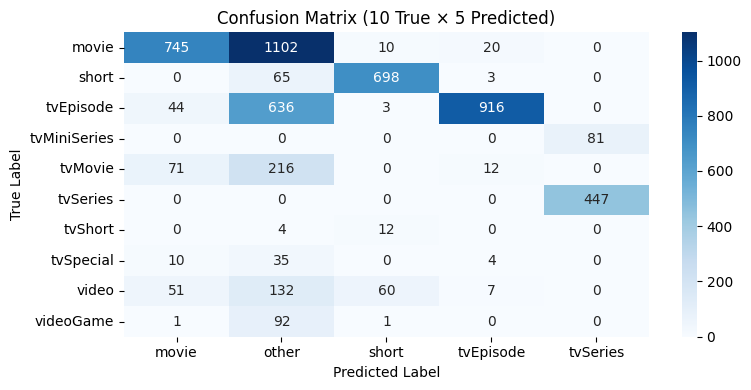

In [42]:
y_test = df_test['titleType'].values
y_pred = df_test.apply(classify_title_type, axis=1).values

# Generate confusion matrix (rectangular) using crosstab
cm_df = pd.crosstab(pd.Series(y_test, name='True'), pd.Series(y_pred, name='Predicted'))

# ensure all labels are represented (fill missing ones)
true_labels = sorted(df_test['titleType'].unique())
pred_labels = sorted(pd.Series(y_pred).unique())
cm_df = cm_df.reindex(index=true_labels, columns=pred_labels, fill_value=0)

plt.figure(figsize=(8, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (10 True × 5 Predicted)')
plt.tight_layout()
plt.show()

## Extraction of rules for awards and nominations

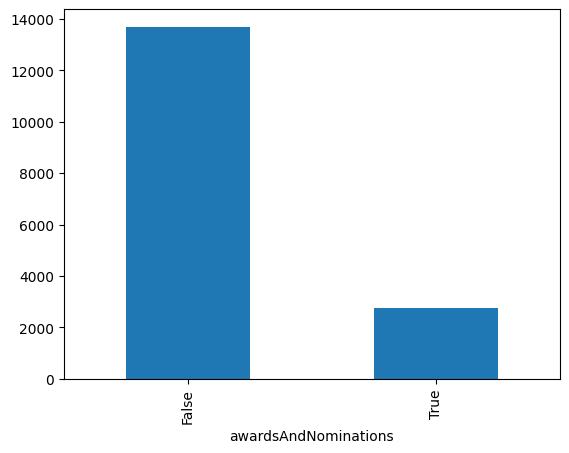

In [43]:
df_copy['awardsAndNominations'].value_counts().plot.bar()
plt.show()

We can establish a baseline performance using a knn classifier.

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay,classification_report

In [45]:
df_copy['logRuntime'] = np.log(df_copy['runtimeMinutes'] + 1)
df_test['logRuntime'] = np.log(df_test['runtimeMinutes'] + 1)

In [46]:
num_cols = ['startYear', 'logRuntime', 'numVotes', 'totalImages', 'totalCredits', 'numRegions', 'numGenres', 'criticReviewsRatio']
target_feat = 'awardsAndNominations'

In [47]:
train_X, train_y = df_copy[num_cols], df_copy[target_feat]
test_X, test_y = df_test[num_cols], df_test[target_feat]

We look for the best parameters using the recall of the positive class as a scorer.
Since the classification problem is unbalanced, the best classifier checks only the nearest neighbor.

In [48]:
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

ks= np.arange(1, 500, 5)
param_grid = {
    "clf__n_neighbors": ks,
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "cityblock"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=splitter,
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [49]:
%time
grid.fit(train_X, train_y)

CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 10.5 μs
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s

[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.2s
[CV] END clf__metric=euclidean,

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'clf__metric': ['euclidean', 'cityblock'],
                         'clf__n_neighbors': array([  1,   6,  11,  16,  21,  26,  31,  36,  41,  46,  51,  56,  61,
        66,  71,  76,  81,  86,  91,  96, 101, 106, 111, 116, 121, 126,
       131, 136, 141, 146, 151, 156, 161, 166, 171, 176, 181, 186, 191,
       196, 201, 206, 211, 216, 221, 226, 231, 236, 241, 246, 251, 256,
       261, 266, 271, 276, 281, 286, 291, 296, 301, 306, 311, 316, 321,
       326, 331, 336, 341, 346, 351, 356, 361, 366, 371, 376, 381, 386,
       391, 396, 401, 406, 411, 416, 421, 426, 431, 436, 441, 446, 451,
       456, 461, 466, 471, 476, 481, 486, 491, 496]),
                         'clf__weights': ['uniform', 'distance']},
             scoring='recall', verbose=2)

In [50]:
print("Recall for positive class in validation (best estimator):", grid.best_score_)

Recall for positive class in validation (best estimator): 0.3760485194624962


In [51]:
knn_pred = grid.best_estimator_.predict(test_X)

In [52]:
print(classification_report(y_true=test_y, y_pred=knn_pred))

              precision    recall  f1-score   support

       False       0.84      0.83      0.84      4582
        True       0.16      0.17      0.16       896

    accuracy                           0.73      5478
   macro avg       0.50      0.50      0.50      5478
weighted avg       0.73      0.73      0.73      5478



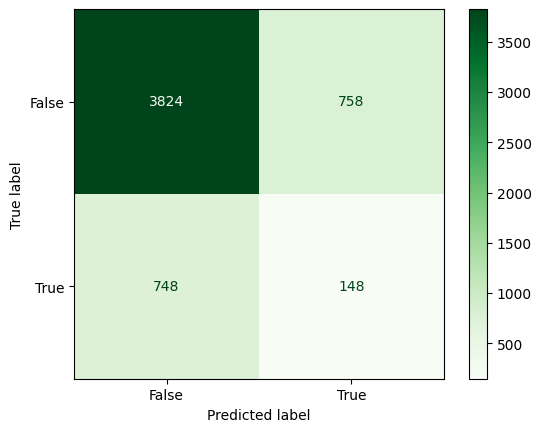

In [53]:
ConfusionMatrixDisplay.from_predictions(y_pred=knn_pred, y_true=test_y, cmap='Greens')

The recall for the positive class is terrible, especially on the test set. 

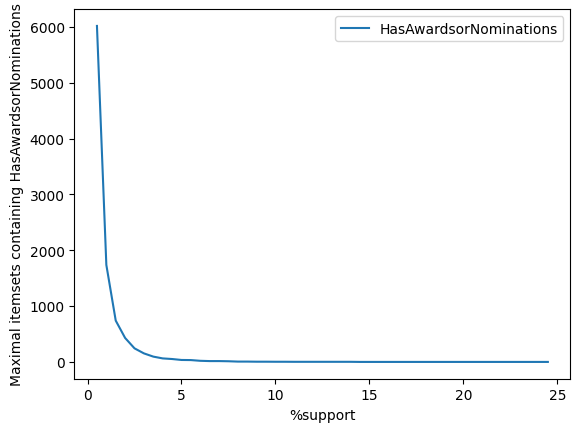

In [54]:
target = 'HasAwardsorNominations'
results = []
min_sup = .5

for i in np.arange(min_sup, max_supp, .5):
    max_itemsets = fpgrowth(X, target="m", supp=i, zmin=zmin)
    results.append(len([item for item in max_itemsets if 'HasAwardsorNominations' in item[0]]))

plt.plot(np.arange(min_sup, max_supp, .5), results, label=target)

plt.legend()
plt.xlabel("%support")
plt.ylabel("Maximal itemsets containing HasAwardsorNominations")
plt.show()

In [55]:
rules = fpgrowth(X, target="r", supp=1, zmin=zmin, conf=60, report="aScl", appear={'HasAwardsorNominations': 'o'})


In [56]:
awards_rules = [rule for rule in rules if rule[0] == 'HasAwardsorNominations']
len(awards_rules)

4292

In [57]:
awards_rules_df = pd.DataFrame(
    awards_rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
awards_rules_df.sort_values('%_support', ascending=False).head(10)

,consequent,antecedent,abs_support,%_support,confidence,lift
3357,HasAwardsorNominations,"(HasVideos, (1.946, 8.162]_TotalImages, (1.386, 4.248]_NumRegions)",479,2.915221,0.608640,3.651176
3182,HasAwardsorNominations,"(HasVideos, (1.946, 8.162]_TotalImages, (1.386, 4.248]_NumRegions, (5.007, 13.782]_NumVotes)",465,2.830016,0.625841,3.754362
708,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, NoEpisodes)",458,2.787414,0.601840,3.610379
719,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType)",458,2.787414,0.601840,3.610379
2705,HasAwardsorNominations,"(HasVideos, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits)",455,2.769156,0.635475,3.812153
2703,HasAwardsorNominations,"(HasVideos, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes)",448,2.726553,0.654015,3.923371
2994,HasAwardsorNominations,"(HasVideos, (1.946, 8.162]_TotalImages, (4.19, 9.664]_TotalCredits)",445,2.708295,0.601351,3.607449
379,HasAwardsorNominations,"((1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, genre_Drama)",438,2.665693,0.646018,3.875399
920,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType)",437,2.659607,0.606103,3.635952
909,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, NoEpisodes)",437,2.659607,0.606103,3.635952


We create a classifier from the 10 rules with maximum support (here lift is always good because only a minority of records received awards of nominations). For this task we use a lower confidence threshold (60%) because we wanted a better recall for the positive class.

In [58]:
def predict_awards_or_nominations(df):
    rule1 = ((df['hasVideos']) & (df['numRegions'] > 1.386) & (df['numRegions'] <= 4.248) & (df['totalImages'] > 1.946) & (df['totalImages'] <= 8.162))
    rule2 = ((df['hasVideos']) & (df['numRegions'] > 1.386) & (df['numRegions'] <= 4.248) & (df['totalCredits'] > 4.19) & (df['totalCredits'] <= 9.664))
    rule3 = ((df['hasVideos']) & (df['totalCredits'] > 4.19) & (df['totalCredits'] < 9.664) & (df['totalImages'] > 1.946) & (df['totalImages'] <= 8.162))
    rule4 = ((df['totalCredits'] > 4.19) & (df['totalCredits'] < 9.664) & (df['totalImages'] > 1.946) & (df['totalImages'] < 8.162) & (df['numVotes'] > 5.007) & (df['numVotes'] < 13.782) & (df['titleType'] == 'Movie'))
    rule5 = ((df['totalCredits'] > 4.19) & (df['totalCredits'] < 9.664) & (df['numVotes'] > 5.007) & (df['numVotes'] <= 13.782) & (df['numRegions'] > 1.386) & (df['numRegions'] <= 4.248) & (df['genres'].apply(lambda x: 'Drama' in x)))
    return rule1 | rule2 | rule3 | rule4 | rule5

In [59]:

df_copy[predict_awards_or_nominations(df_copy)]['awardsAndNominations'].value_counts()


awardsAndNominations
True     731
False    637
Name: count, dtype: int64

We can see that our set of rules is not very precise on the training test.

In [60]:
rules_pred = predict_awards_or_nominations(df_test)

In [61]:
print(classification_report(y_true=test_y, y_pred=rules_pred))

              precision    recall  f1-score   support

       False       0.84      0.95      0.89      4582
        True       0.26      0.09      0.14       896

    accuracy                           0.81      5478
   macro avg       0.55      0.52      0.52      5478
weighted avg       0.75      0.81      0.77      5478



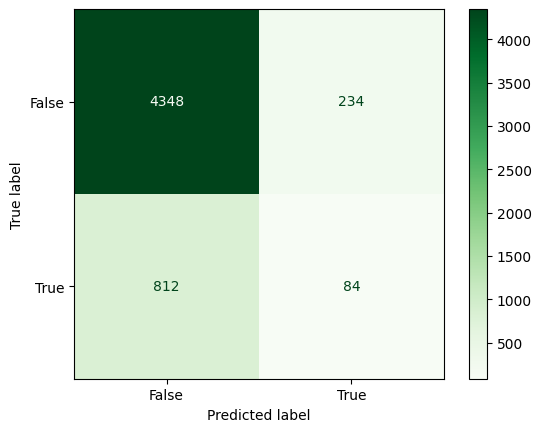

In [62]:
ConfusionMatrixDisplay.from_predictions(y_true=test_y, y_pred=rules_pred, cmap="Greens")

And the performace on the test set is markedly worse than that of the nearest neighbor classifier that we used as a baseline.
Conclusion: we were unable to extract rules to reliably predict if some record would receive awards or nominations.

In [63]:
awards_rules_df.sort_values('confidence', ascending=False).head(10)

,consequent,antecedent,abs_support,%_support,confidence,lift
1568,HasAwardsorNominations,"((90.0, 3000.0]_RuntimeMin, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, genre_Drama, country_Other, NoEpisodes)",141,0.858134,0.839286,5.034795
230,HasAwardsorNominations,"((0.227, 1.0]_CriticReviewsRatio, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other)",140,0.852048,0.838323,5.029022
229,HasAwardsorNominations,"((0.227, 1.0]_CriticReviewsRatio, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other, NoEpisodes)",140,0.852048,0.838323,5.029022
1569,HasAwardsorNominations,"((90.0, 3000.0]_RuntimeMin, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, genre_Drama, country_Other)",143,0.870306,0.821839,4.930134
1223,HasAwardsorNominations,"((90.0, 3000.0]_RuntimeMin, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other)",157,0.955511,0.817708,4.905354
1222,HasAwardsorNominations,"((90.0, 3000.0]_RuntimeMin, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other, NoEpisodes)",157,0.955511,0.817708,4.905354
716,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other, NoEpisodes)",148,0.900736,0.817680,4.905182
717,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other)",148,0.900736,0.817680,4.905182
918,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other)",137,0.833790,0.815476,4.891964
917,HasAwardsorNominations,"((1.946, 8.162]_TotalImages, (1.386, 4.248]_NumRegions, (4.19, 9.664]_TotalCredits, (5.007, 13.782]_NumVotes, movie_TitleType, genre_Drama, country_Other, NoEpisodes)",137,0.833790,0.815476,4.891964


Analyzing the rules with highest confidence, we can see that for dramatic movies not produced in one of the top 4 countries (US, UK, Japan or France), "popularity", represented mainly by a higher number of votes and images, and productions of bigger dimensions (high number of credits) are reliably associated with awards and nominations (almost 82% vs 66% for productions from one of the top 4 countries).

This may very well indicate that the quality threshold for movies not from top countries to become very popular is higher or that foreign movies need critical acclaim to become popular.

In [64]:
def is_popular_dramatic_movie(df):
    movie = (df['titleType'] == 'movie') & (df['runtimeMinutes'] > 90)
    dramatic = df['genres'].apply(lambda x: 'Drama' in x)
    popular = df['numVotes'] > 5.007
    big_production = df['totalCredits'] > 4.192
    return movie & dramatic & popular & big_production

In [65]:
def only_top_countries(countries):
    return all([c in top_countries for c in countries])

In [66]:
df_copy['top_countries'] = df_copy['countryOfOrigin'].apply(only_top_countries)
df_copy[is_popular_dramatic_movie(df_copy)].groupby('top_countries')['awardsAndNominations'].value_counts()

top_countries  awardsAndNominations
False          True                    157
               False                    35
True           True                    120
               False                    61
Name: count, dtype: int64